# Big Mart Sales Prediction

**We have train (8523) and test (5681) data set, train data set has both input and output variable(s). We need to predict the sales for test data set.**

**First Import all the libraries that are needed in our analysis**

In [1]:
#Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
#Load the data set
test = pd.read_csv("test.csv")
train = pd.read_csv("train.csv")

In [4]:
#check the shape of the data sets
train.shape, test.shape

((8523, 12), (5681, 11))

In [5]:
train.columns

Index(['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility',
       'Item_Type', 'Item_MRP', 'Outlet_Identifier',
       'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type',
       'Outlet_Type', 'Item_Outlet_Sales'],
      dtype='object')

In [6]:
test.columns

Index(['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility',
       'Item_Type', 'Item_MRP', 'Outlet_Identifier',
       'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type',
       'Outlet_Type'],
      dtype='object')

**We need to predict the the item_outlet_sales for given test data**
**lest merge train and test for EDA**

In [8]:
train['source'] = 'train'
test['source'] = 'test'
test['Item_Outlet_Sales'] = 0
data = pd.concat([train, test], sort=False)
print(data.shape)

(14204, 13)


In [9]:
data['Item_Outlet_Sales'].describe()

count    14204.000000
mean      1308.865489
std       1699.791423
min          0.000000
25%          0.000000
50%        559.272000
75%       2163.184200
max      13086.964800
Name: Item_Outlet_Sales, dtype: float64

In [ ]:
data['Item_Outlet_Sales'].unique()

array([3735.138 ,  443.4228, 2097.27  , ..., 3608.636 , 2778.3834,
          0.    ], shape=(3494,))

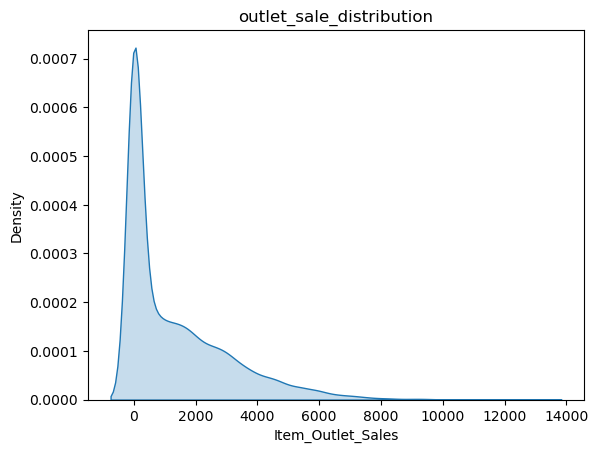

In [16]:
sns.kdeplot(data=data, x="Item_Outlet_Sales", fill=True)
plt.title("outlet_sale_distribution")
plt.show()

**1. Deviate from the normal distribution.**

**2. Have appreciable positive skewness.**

**3. Show peakedness.**

In [19]:
print("Skewness: %f" % data['Item_Outlet_Sales'].skew())
print("kurtosis: %f" % data['Item_Outlet_Sales'].kurt())

Skewness: 1.544684
kurtosis: 2.419439


**Now check the data types of the variables**

In [20]:
data.dtypes

Item_Identifier               object
Item_Weight                  float64
Item_Fat_Content              object
Item_Visibility              float64
Item_Type                     object
Item_MRP                     float64
Outlet_Identifier             object
Outlet_Establishment_Year      int64
Outlet_Size                   object
Outlet_Location_Type          object
Outlet_Type                   object
Item_Outlet_Sales            float64
source                        object
dtype: object

In [23]:
categorical_features = data.select_dtypes(include=["object"])
categorical_features.head(4)

,Item_Identifier,Item_Fat_Content,Item_Type,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type,source
0,FDA15,Low Fat,Dairy,OUT049,Medium,Tier 1,Supermarket Type1,train
1,DRC01,Regular,Soft Drinks,OUT018,Medium,Tier 3,Supermarket Type2,train
2,FDN15,Low Fat,Meat,OUT049,Medium,Tier 1,Supermarket Type1,train
3,FDX07,Regular,Fruits and Vegetables,OUT010,NaN,Tier 3,Grocery Store,train


In [24]:
numerical_features = data.select_dtypes(include=["float"])
numerical_features.head(4)

,Item_Weight,Item_Visibility,Item_MRP,Item_Outlet_Sales
0,9.30,0.016047,249.8092,3735.1380
1,5.92,0.019278,48.2692,443.4228
2,17.50,0.016760,141.6180,2097.2700
3,19.20,0.000000,182.0950,732.3800


In [25]:
data['Outlet_Establishment_Year'].value_counts()

Outlet_Establishment_Year
1985    2439
1987    1553
1999    1550
1997    1550
2004    1550
2002    1548
2009    1546
2007    1543
1998     925
Name: count, dtype: int64